# Define functions

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_matrix_panel(ax, ppm, specs, time_labels,
                      xlim=(6, 1),
                      lw=1.2,
                      color="black",
                      linestyle="-",
                      alpha=1.0,
                      offset=None,
                      offset_ppm_window=(5.6, 3.0),   # peak-rich window for spacing
                      offset_frac=0.4,                # keeps peaks "not squished"
                      dx_ppm_total=0.0,               # SMALL shear across all traces (paper-safe)
                      label_outside=True,
                      zorder=2):
    """
    Matrix/Waterfall plot with optional small lateral (dx) offset.
    specs: (K,F), ppm descending 8->1
    """
    specs = np.asarray(specs)
    K, F = specs.shape

    # --- compute dy offset from a peak-rich window (so peaks stay visually large) ---
    if offset is None:
        lo, hi = offset_ppm_window
        mask = (ppm <= lo) & (ppm >= hi) if lo > hi else (ppm >= lo) & (ppm <= hi)
        ref = specs[:, mask] if np.any(mask) else specs
        amp = np.percentile(ref, 99.5) - np.percentile(ref, 1.0)
        offset = offset_frac * amp if amp > 0 else 1.0

    # --- compute small dx ---
    dx = dx_ppm_total / max(K - 1, 1)

    # plot from bottom to top (k=0 bottom, k=K-1 top)
    for k in range(K):
        y = specs[k] + k * offset
        x = ppm + k * dx

        ax.plot(x, y, lw=lw, color=color, linestyle=linestyle, alpha=alpha, zorder=zorder)

        # label near right edge, outside axis to avoid overlap
        idx = np.argmin(np.abs(ppm - xlim[1]))
        if label_outside:
            ax.text(
                1.02, y[idx], time_labels[k],
                transform=ax.get_yaxis_transform(),  # x in axes coords, y in data coords
                va="center", ha="left", fontsize=12, color="black",
                bbox=dict(facecolor="white", edgecolor="none", pad=0.3),
                clip_on=False
            )
        else:
            ax.text(xlim[1] + 0.03*(xlim[0]-xlim[1]), y[idx], time_labels[k],
                    va="center", ha="left", fontsize=12, color="black")

    # styling
    ax.set_xlim(xlim[0] + (K - 1) * dx, xlim[1])  # expand left due to dx
    ax.set_yticks([])
    for s in ["left", "right", "top"]:
        ax.spines[s].set_visible(False)
    ax.tick_params(axis="y", length=0, labelsize=20)
    ax.tick_params(axis="x", length=0, labelsize=12)
    ax.margins(y=0.12)

    return offset


DEFAULT_COLORS = {
    "noisy": "#333333",          # dark gray
    "tMPPCA_5D": "#E69F00",       # orange
    "deep_tMPPCA_5D": "#009E73",  # green
    "gt": "#000000"              # black (for dashed GT)
}


def plot_noisy_vs_methods(
    Noisy, Method1, Method2=None,
    ppm=None,
    x=0, y=0, z=0,
    t_idx=(0, 3, 6, 9),
    time_labels=None,
    titles=("Noisy", "Proposed + GT"),
    colors=DEFAULT_COLORS,
    dx_ppm_total=0.20,
    add_legend=True,
    anatomy=None,
    anatomy_title="",
    anatomy_clim=None,          # <<< NEU (z.B. T1_WINDOW)
):
    """
    Left : Noisy (stacked spectra)
    Mid  : Method1 (solid) + optional Method2 (dashed, overlay)
    Right: Optional anatomy panel (imshow of 2D array)

    Specmaps: (X,Y,Z,F,T)
    """

    if ppm is None:
        F = Noisy.shape[3]
        ppm = np.linspace(8, 1, F)

    if time_labels is None:
        time_labels = [f"T{t+1}" for t in t_idx]

    # --- extract spectra ---
    def extract(specmap):
        S = specmap[x, y, z, :, :]
        return S[:, t_idx].T

    noisy_specs = extract(Noisy)
    m1_specs    = extract(Method1)
    m2_specs    = extract(Method2) if Method2 is not None else None

    # --- figure / axes ---
    if anatomy is None:
        fig, axs = plt.subplots(1, 2, figsize=(6, 3), sharex=True)
        axs_noisy, axs_mid = axs[0], axs[1]
        axs_anat = None
        fig.subplots_adjust(wspace=0.25)
    else:
        fig, axs = plt.subplots(
            1, 3, figsize=(8.5, 3),
            gridspec_kw={"width_ratios": [1.0, 1.0, 0.85]}
        )
        axs_noisy, axs_mid, axs_anat = axs
        fig.subplots_adjust(wspace=0.35)

    # LEFT: Noisy
    offset = plot_matrix_panel(
        axs_noisy, ppm, noisy_specs, time_labels,
        color=colors["noisy"],
        lw=1.0,
        linestyle="-",
        zorder=1,
        dx_ppm_total=0.0
    )
    axs_noisy.set_title(titles[0], fontsize=12)
    axs_noisy.set_xlabel("Chemical shift [ppm]", fontsize=12)

    # MID: Proposed
    plot_matrix_panel(
        axs_mid, ppm, m1_specs, time_labels,
        color=colors["deep_tMPPCA_5D"],
        lw=1.4,
        linestyle="-",
        offset=offset,
        zorder=3,
        dx_ppm_total=0.0
    )

    # MID: GT
    if m2_specs is not None:
        plot_matrix_panel(
            axs_mid, ppm, m2_specs, time_labels,
            color=colors["gt"],
            lw=1.1,
            linestyle="--",
            offset=offset,
            alpha=0.9,
            zorder=4,
            dx_ppm_total=0.0
        )

    axs_mid.set_title(titles[1], fontsize=12)
    axs_mid.set_xlabel("Chemical shift [ppm]", fontsize=12)

    if add_legend and (m2_specs is not None):
        handles = [
            Line2D([0], [0], color=colors["deep_tMPPCA_5D"], lw=1.4, linestyle="-", label="Proposed"),
            Line2D([0], [0], color=colors["gt"], lw=1.1, linestyle="--", label="Ground truth"),
        ]
        axs_mid.legend(handles=handles, loc="upper left", frameon=False, fontsize=10)

    # RIGHT: Anatomy panel
    if axs_anat is not None:
        if anatomy_clim is not None:
            vmin, vmax = anatomy_clim
            axs_anat.imshow(
                anatomy, cmap="gray",
                vmin=vmin, vmax=vmax,
                interpolation="nearest"
            )
        else:
            axs_anat.imshow(anatomy, cmap="gray", interpolation="nearest")

        axs_anat.set_title(anatomy_title, fontsize=12)
        axs_anat.set_xticks([])
        axs_anat.set_yticks([])
        for s in ["left", "right", "top", "bottom"]:
            axs_anat.spines[s].set_visible(False)

    plt.tight_layout()
    return fig, axs


def load_nifti_ras(path, *, dtype=None, return_affine=False, return_transform=False):
    """
    Load a NIfTI (.nii/.nii.gz) and reorient the data to RAS+ (FreeView-like).

    Parameters
    ----------
    path : str
        Path to NIfTI file.
    dtype : numpy dtype or None
        If set, cast output array to this dtype.
    return_affine : bool
        If True, also return the original NIfTI affine (voxel->world).
    return_transform : bool
        If True, also return the orientation transform used (useful to apply to other arrays).

    Returns
    -------
    data_ras : np.ndarray
        Data reoriented to RAS+ (same voxel values, axes/flips fixed).
    (optional) affine : np.ndarray
        Original affine from file.
    (optional) transform : np.ndarray
        Orientation transform mapping original->RAS (for nibabel.apply_orientation).
    """
    import numpy as np
    import nibabel as nib
    from nibabel.orientations import io_orientation, axcodes2ornt, ornt_transform, apply_orientation

    nii = nib.load(path)
    data = nii.get_fdata()

    # Build transform: original orientation -> RAS
    ornt_orig = io_orientation(nii.affine)
    ornt_ras = axcodes2ornt(("R", "A", "S"))
    transform = ornt_transform(ornt_orig, ornt_ras)

    # Apply to first 3 dims (XYZ). If more dims exist, fold/restack safely.
    if data.ndim < 3:
        raise ValueError(f"Expected at least 3D NIfTI, got shape {data.shape}")

    xyz = data.shape[:3]
    rest = data.shape[3:]
    if rest:
        data2 = data.reshape(*xyz, int(np.prod(rest)))
        data2_ras = apply_orientation(data2, transform)
        data_ras = data2_ras.reshape(*data2_ras.shape[:3], *rest)
    else:
        data_ras = apply_orientation(data, transform)

    if dtype is not None:
        data_ras = data_ras.astype(dtype, copy=False)

    outs = [data_ras]
    if return_affine:
        outs.append(nii.affine)
    if return_transform:
        outs.append(transform)
    return outs[0] if len(outs) == 1 else tuple(outs)


# Beispiel:
# Tumor = load_nifti_ras("magnitudeTumor1.nii")
# Tumor, affine, transform = load_nifti_ras("magnitudeTumor1.nii", return_affine=True, return_transform=True)


# Sim Sachen LAden

In [79]:
import numpy as np 
import matplotlib.pyplot as plt
import nibabel as nib

GT = np.load("MetabMaps/Lesion_Double_GT/Spectra_Lesion_Double_GT.npy")[...,:166,:] # cropped to 1 to 8 ppm instead of 0.5 to 8
Proposed = np.load("MetabMaps/Lesion_double_deep_tmppca_1/Spectra_Lesion_double_deep_tmppca_1.npy")[...,:166,:]
tMPPCA = np.load("MetabMaps/Lesion_double_tmppca_1/Spectra_Lesion_double_tmppca_1.npy")[...,:166,:]
Noisy = np.load("MetabMaps/Lesion_double_noisy_1/Spectra_Lesion_double_noisy_1.npy")[...,:166,:]

# Note: The way this is loaded above makes sure that the indices match exactly what you see in freeview

# L
Glx = np.load("MetabMaps/Lesion_Double_GT/Glx_amp_Lesion_Double_GT_Orig.npy")
Glx = np.swapaxes(Glx, 0,2)
Glx = np.flip(Glx, 0)
Glx = np.flip(Glx, 1)  # this is now exactly oriented as in freeview, with exakt same indices as shown in freeview

# Läsionsmaske
nii = nib.load("Lesion_Double_lr.nii")          # oder .nii.gz
Lesion = nii.get_fdata()              # numpy array (float)

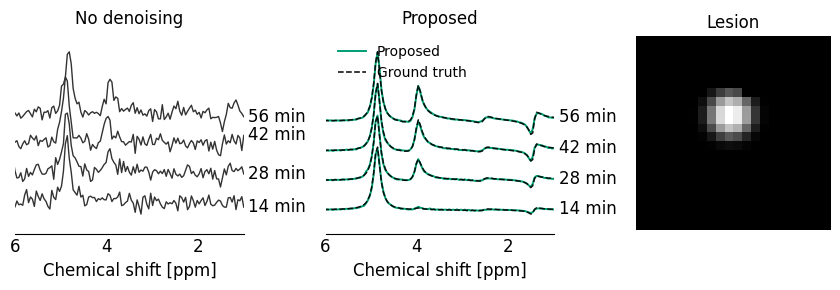

In [80]:
ppm = np.linspace(8, 1, 166)

fig, axs = plot_noisy_vs_methods(
    Noisy,
    Proposed,
    Method2=GT,          # dashed overlay
    ppm=ppm,
    x=14, y=11, z=15,
    t_idx=[0, 2, 4, 6],
    time_labels=["14 min", "28 min", "42 min", "56 min"],
    titles=("No denoising", "Proposed"),
    anatomy=Lesion[...,15],
    anatomy_title="Lesion",
    #linestyles=("-", "--")
)

plt.savefig("SpectraSim.pdf", bbox_inches="tight")
plt.show()

# InVivo Healthy

In [81]:
Proposed = np.load("MetabMaps/P08_deep_tMPPCA_5D/Spectra_P08_deep_tMPPCA_5D.npy")[...,:162,:]#[...,:166,:]
Noisy = np.load("MetabMaps/P08_noisy/Spectra_P08_noisy.npy")[...,:162,:]

Anatomy = load_nifti_ras("magnitudeP08.nii")
Anatomy = np.swapaxes(Anatomy, 0, 1)
Anatomy = np.flip(Anatomy, 0)

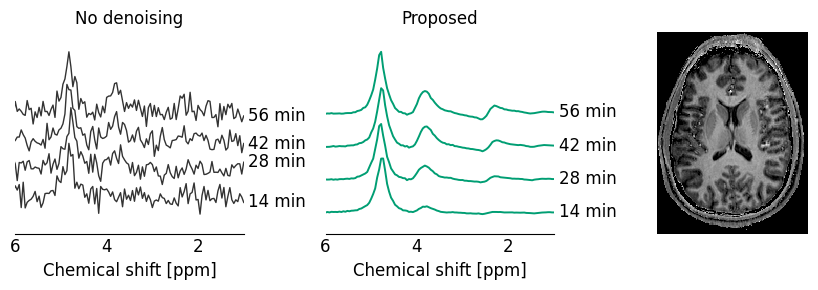

In [82]:
ppm = np.linspace(8, 1, 162)

fig, axs = plot_noisy_vs_methods(
    Noisy,
    Proposed,
    #Method2=GT,          # dashed overlay
    ppm=ppm,
    x=8, y=11, z=11,
    t_idx=[0, 2, 4, 6],
    time_labels=["14 min", "28 min", "42 min", "56 min"],
    titles=("No denoising", "Proposed"),
    anatomy = Anatomy[..., 106],
    anatomy_clim=(1268, 3619),
    #linestyles=("-", "--")
)
plt.savefig("SpectraHealthy.pdf", bbox_inches="tight")
plt.show()

# In Vivo Tumor

In [83]:
Noisy = np.load("MetabMaps/Tumor_1_noisy/Spectra_Tumor_1_noisy.npy")#[...,:166,:] schneide 2 ppm weg also von 6 bis 1ppm 
Proposed = np.load("MetabMaps/Tumor_1_deep_tMPPCA_5D/Spectra_Tumor_1_deep_tMPPCA_5D.npy")

Tumor = load_nifti_ras("magnitudeTumor1.nii")
Tumor = np.swapaxes(Tumor, 0, 1)
Tumor = np.flip(Tumor, 0)

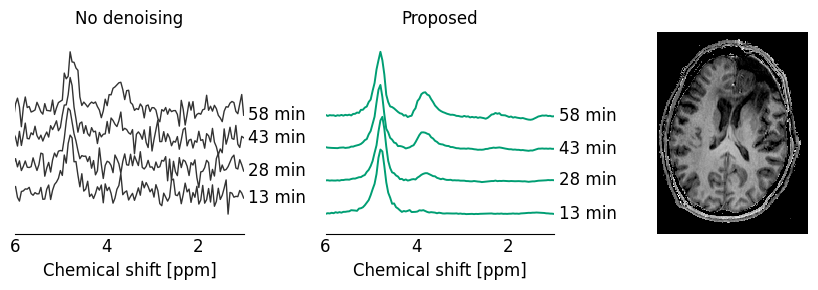

In [86]:
ppm = np.linspace(8, 1, 165)

fig, axs = plot_noisy_vs_methods(
    Noisy,
    Proposed,
    #Method2=GT,          # dashed overlay
    ppm=ppm,
    x=13, y=15, z=11,
    t_idx=[0, 3, 6, 9],
    time_labels=["13 min", "28 min", "43 min", "58 min"],
    titles=("No denoising", "Proposed"),
    anatomy = Tumor[..., 113],
    anatomy_clim=(1268, 3619),
    #linestyles=("-", "--")
)

plt.savefig("SpectraTumor.pdf", bbox_inches="tight")
plt.show()

# test

In [85]:
Lesion.shape

(22, 22, 21)